# **"Implementation of the Isolation Forest Algorithm in Detecting Anomalous Parameters in Four-Wheeled Vehicle Data"**

##🧠 Goals:
####**Mendeteksi fitur (parameter sensor) yang menyimpang** pada data kendaraan yang memiliki kode kerusakan P0351, P0352, P0353, dan P0354 (Ignition Coil "A, B, C, dan D") menggunakan:
####**Algoritma Isolation Forest** → untuk deteksi anomali
####**SHAP (SHapley Additive exPlanations)** → untuk menjelaskan fitur mana yang berkontribusi pada anomali

### Vehicle Data: [Data Normal & Data Symptomatic](https://drive.google.com/drive/folders/1mM41Pv54S8DdGpfYMicOhzKU_avdYhTk?usp=sharing)

### Tidak menggunakan parameter numerik (konstan), parameter sinyal, parameter sinyal biner (changing), parameter spesifikasi

## *1. Import Data*

In [58]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split

In [ ]:
# Import Data Kendaraan Normal dan Rusak
data_normal = pd.read_csv('Trouble Scenario Data (Label)/Real Data/Label/Normal Data (Toyota) Label.csv')
data_symptomatic = pd.read_csv('Trouble Scenario Data (Label)/Real Data/Label/Failure Data (Toyota) Label.csv')

In [61]:
# Ringkasan Tabel
display(Markdown("### Jumlah Data"))

summary = pd.DataFrame({
    "Dataset": ["Data Normal", "Data Symptomatic"],
    "Jumlah Baris": [data_normal.shape[0], data_symptomatic.shape[0]],
    "Jumlah Kolom": [data_normal.shape[1], data_symptomatic.shape[1]]
})

# Tambahkan total
total_baris = data_normal.shape[0] + data_symptomatic.shape[0]
total_kolom = data_normal.shape[1]
summary.loc[len(summary.index)] = ["Total", total_baris, total_kolom]

display(summary)


### Jumlah Data

,Dataset,Jumlah Baris,Jumlah Kolom
0,Data Normal,198,92
1,Data Symptomatic,198,92
2,Total,396,92


In [62]:
# Tampilkan 5 data pertama
display(Markdown("### Data Normal (5 Baris Pertama)"))
display(data_normal.head())

display(Markdown("### Data Kondisi Rusak (5 Baris Pertama)"))
display(data_symptomatic.head())

### Data Normal (5 Baris Pertama)

,SampleTime,VehicleSpeed,EngineSpeed,CalculateLoad,MAF,AtmospherePressure,CoolantTemp,IntakeAir,EngineRunTime,InitialEngineCoolantTemp,...,IdleFuelCut,FCTAU,ModelCode,EngineType,CylinderNumber,TransmissionType,Destination,ModelYear,SystemIdentification,Label
0,00:00.000,0,753,19.6,2.93,97,75,28,271,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
1,00:00.282,0,756,19.6,2.96,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
2,00:00.565,0,759,19.2,2.92,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
3,00:00.847,0,749,20.0,2.96,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
4,00:01.130,0,756,19.6,2.95,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal


### Data Kondisi Rusak (5 Baris Pertama)

,SampleTime,VehicleSpeed,EngineSpeed,CalculateLoad,MAF,AtmospherePressure,CoolantTemp,IntakeAir,EngineRunTime,InitialEngineCoolantTemp,...,IdleFuelCut,FCTAU,ModelCode,EngineType,CylinderNumber,TransmissionType,Destination,ModelYear,SystemIdentification,Label
0,00:00.000,0,705,18.0,2.53,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
1,00:00.324,0,706,18.0,2.51,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
2,00:00.606,0,710,17.6,2.51,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
3,00:00.889,0,707,17.6,2.50,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
4,00:01.171,0,703,18.0,2.53,101,85,30,890,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali


## *2. Preprocessing Data*


#### Data Intergration (Penggabunggan Data)

In [63]:
# Gabungkan kedua data (Data Normal + Data Symptomatic (Data Kendaraan Rusak))
data_all = pd.concat([data_normal, data_symptomatic], ignore_index=True)

In [64]:
print (data_all.dtypes)

SampleTime               object
VehicleSpeed              int64
EngineSpeed               int64
CalculateLoad           float64
MAF                     float64
                         ...   
TransmissionType          int64
Destination               int64
ModelYear                 int64
SystemIdentification      int64
Label                    object
Length: 92, dtype: object


#### Checking Missing Value

In [65]:
# Cek missing value
missing_count = data_all.isnull().sum().sum()

print("Tidak ada missing value dalam dataset.")

if missing_count == 0:
    print("Tidak ada missing value dalam dataset.")
    df = data_all.copy()
else:
    print(f"Ditemukan {missing_count} missing value. Menghapus baris yang mengandung nilai kosong.")
    df = data_all.dropna()
    # Alternatif jika ada nilai kosong:
    df = data_al.fillna(method='ffill')
    df = data_al.fillna(data.mean())

Tidak ada missing value dalam dataset.
Tidak ada missing value dalam dataset.


#### Checking Duplicate Data

In [66]:
def cek_duplikat(dataframe, nama_dataset):
    # Tentukan kolom yang diperiksa (kecuali SampleTime dan label)
    cols_to_check = [col for col in dataframe.columns if col not in ['SampleTime', 'label']]

    # Deteksi duplikat
    duplicate_rows = dataframe.duplicated(subset=cols_to_check, keep=False)
    duplicate_count = duplicate_rows.sum()

    # Tampilkan hasil
    if duplicate_count == 0:
        print(f"Tidak ada duplikat dalam {nama_dataset}.")
    else:
        print(f"Terdapat {duplicate_count} baris duplikat dalam {nama_dataset}. Menampilkan contoh:")
        display(dataframe[duplicate_rows].head())

        # (Opsional) Hapus duplikat jika ingin
        print(f"Menghapus duplikat dari {nama_dataset}...")
        dataframe = dataframe.drop_duplicates(subset=cols_to_check)
        print(f"Duplikat dalam {nama_dataset} berhasil dihapus.")

    return dataframe

# 🔍 Cek masing-masing dataset secara terpisah
data_normal = cek_duplikat(data_normal, "Data Normal")
data_symptomatic = cek_duplikat(data_symptomatic, "Data Symptomatic")

# 🔗 Gabungkan kembali setelah duplikat dihapus (jika diinginkan)
data_all = pd.concat([data_normal, data_symptomatic], ignore_index=True)
df = data_all.copy()


Tidak ada duplikat dalam Data Normal.
Tidak ada duplikat dalam Data Symptomatic.


#### Drop Feature (Feature Selection)

In [67]:
fitur_dibuang = [
    # --- Parameter Numerik ---
    # "CalculateLoad", "MAF", "CoolantTemp", #"BatteryVoltage",
    # "AccelSens.No.1Volt%", "AccelSens.No.2Volt%", "AccelSensorOutNo.1",
    # "AccelSensorOutNo.2", "AccelFullyClose#1(AD)", "AccelFullyCloseLearn#1",
    # "AccelFullyCloseLearn#2", "ThrottleSensorVolt%", "ThrottleSensor2Volt%",
    # "ThrottleRequirePosition", "ThrottleSensorPosition", "ThrottlePositionNo.1",
    # "ThrottlePositionNo.2", "ThrottlePositionCommand", "ThrottleSensOpen#1(AD)",
    # "ThrottleMotorCurrent", "ThrottleMotorDUTY", "ThrottleMotorDuty(Open)",
    # "ThrottleMotorDuty(Close)", "+BMVoltage", "Injector(Port)", "InjectionVolum(Cylinder1)",
    # "EvapPurgeFlow", "TargetAir-FuelRatio", "O2SB1S1", "ShortFTB1S1", "LongFTB1S1", "O2FTB1S1", "IGNAdvance",

    # --- Parameter Numerik (Tidak digunakan) ---
    "SampleTime", "EngineRunTime","EngineSpeed", "VehicleSpeed",
    "IntakeAir", "InitialEngineCoolantTemp", "InitialIntakeAirTemp", "AtmospherePressure", "ThrottleFullyCloseLearn", "ThrottleSensOpenPos#1",
    "KnockFeedbackValue", "KnockCorrectLearnValue",


    # --- Parameter Sinyal (Konstan) ---
    "FCTAU", "TCandTE1", "ElectricalLoadSignal", "A/CSignal", "StopLightSwitch",
    "PowerSteeringSignal", "StarterSignal", "VVTOCVDuty#1", "VVTChangeAngle#1", "VVTAimAngle#1", "EVAPPurgeVSV",
    "EVAPPurgeVSV", "OpenSideMalfunction", "ST1", "ACTVSV", "PowerSteer.Sig.Record", "FuelSystemStatus#1",
    "FuelPump/SpeedStatus", "ActuatorPowerSupply", "ETCSActuatorPower", "ThrottleMotor",
    "ThrottleSensOpenPos#2", "SystemGuard",

    # --- Parameter Sinyal (Changing) ---
    "AcceleratorIdlePosition", "ThrottleIdlePosition", "VVTControlStatus#1",
    "ClosedThrottlePositionSW", "IdleFuelCut",
    "PurgeDensityLearnValue",

    # --- Parameter Spesifikasi/Identitas ---
    "FailSafeDrive", "FailSafeDrive(MainCPU)", "CheckMode",
    "SPDTestResult", "#Codes(IncludeHistory)", "MIL", "TimeafterDTCCleared",
    "DistancefromDTCCleared", "WarmupCycleClearedDTC", "OBDRequirements", "NumberofEmissionDTC",
    "ModelCode", "EngineType", "CylinderNumber", "TransmissionType", "Destination", "ModelYear",
    "SystemIdentification"
]

# --- Filter hanya kolom yang memang ada di df ---
fitur_dibuang_valid = [f for f in fitur_dibuang if f in df.columns]

# --- Drop fitur ---
if fitur_dibuang_valid:
    print(f'Menghapus fitur: {fitur_dibuang_valid}')
    df_reduced = df.drop(columns=fitur_dibuang_valid)
else:
    print('ℹTidak ada fitur yang sesuai untuk dihapus.')
    df_reduced = df.copy()

# --- Output hasil ---
print(f'Dataset akhir memiliki {df_reduced.shape[1]} fitur dan {df_reduced.shape[0]} baris.')

# --- Tampilkan 5 data pertama ---
print('\nData setelah fitur dibuang:')
display(df_reduced.head())


Menghapus fitur: ['SampleTime', 'EngineRunTime', 'EngineSpeed', 'VehicleSpeed', 'IntakeAir', 'InitialEngineCoolantTemp', 'InitialIntakeAirTemp', 'AtmospherePressure', 'ThrottleFullyCloseLearn', 'ThrottleSensOpenPos#1', 'KnockFeedbackValue', 'KnockCorrectLearnValue', 'FCTAU', 'TCandTE1', 'ElectricalLoadSignal', 'A/CSignal', 'StopLightSwitch', 'PowerSteeringSignal', 'StarterSignal', 'VVTOCVDuty#1', 'VVTChangeAngle#1', 'VVTAimAngle#1', 'EVAPPurgeVSV', 'EVAPPurgeVSV', 'OpenSideMalfunction', 'ST1', 'ACTVSV', 'PowerSteer.Sig.Record', 'FuelSystemStatus#1', 'FuelPump/SpeedStatus', 'ActuatorPowerSupply', 'ETCSActuatorPower', 'ThrottleMotor', 'ThrottleSensOpenPos#2', 'SystemGuard', 'AcceleratorIdlePosition', 'ThrottleIdlePosition', 'VVTControlStatus#1', 'ClosedThrottlePositionSW', 'IdleFuelCut', 'PurgeDensityLearnValue', 'FailSafeDrive', 'FailSafeDrive(MainCPU)', 'CheckMode', 'SPDTestResult', '#Codes(IncludeHistory)', 'MIL', 'TimeafterDTCCleared', 'DistancefromDTCCleared', 'WarmupCycleClearedDTC

,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,Injector(Port),InjectionVolum(Cylinder1),EvapPurgeFlow,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance,Label
0,19.6,2.93,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.44,-1.6,2.3,-1.563,8.5,Normal
1,19.6,2.96,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,0.0,2.3,0.000,7.5,Normal
2,19.2,2.92,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,0.7,2.3,0.781,7.0,Normal
3,20.0,2.96,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,1.5,2.3,1.562,7.5,Normal
4,19.6,2.95,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,2.3,2.3,2.343,6.5,Normal


#### Data Transformation (StandarScaler)

In [68]:
# --- Asumsikan df_reduced punya kolom 'Label' ---
X = df_reduced.drop(columns=['Label'])
y = df_reduced['Label'].apply(lambda x: 1 if x == 'Anomali' else 0)  # 1=Anomali, 0=Normal

# --- Standarisasi seluruh fitur terlebih dahulu ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Ubah kembali ke DataFrame agar mudah digunakan ---
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [69]:
# --- Pilih parameter yang ingin ditampilkan ---
param = 'CalculateLoad'

# --- Ambil 5 baris acak berdasarkan indeks dari data asli ---
sample_idx = X.sample(5, random_state=42).index

# --- Buat DataFrame perbandingan sebelum & sesudah standarisasi ---
df_compare = pd.DataFrame({
    'Before_Standardization': X.loc[sample_idx, param].values,
    'After_Standardization': X_scaled.loc[sample_idx, param].values
}).reset_index(drop=True)

print(f"Perbandingan nilai '{param}' sebelum dan sesudah standarisasi (5 baris acak):")
display(df_compare)


Perbandingan nilai 'CalculateLoad' sebelum dan sesudah standarisasi (5 baris acak):


,Before_Standardization,After_Standardization
0,9.0,-1.283999
1,18.0,-0.266529
2,17.6,-0.311750
3,20.0,-0.040425
4,23.9,0.400479


## *3. Exploratory Data Analysis*


#### Statistik Deskriptif

In [70]:
display(Markdown("## Statistik Deskriptif"))
display(df_reduced.describe())

## Statistik Deskriptif

,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,+BMVoltage,Injector(Port),InjectionVolum(Cylinder1),EvapPurgeFlow,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance
count,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,...,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000
mean,20.357576,5.564141,81.424242,13.645707,18.081313,34.019697,0.848990,1.622475,0.848990,19.830808,...,13.613889,2.466843,0.122621,0.518687,0.999934,0.431818,0.584848,1.637879,0.623073,14.457071
std,8.856660,5.238837,3.832812,0.135970,4.512273,4.487481,0.222924,0.227979,0.222924,0.370303,...,0.187681,0.857915,0.048245,0.725244,0.000248,0.339845,2.533487,1.254190,2.536514,10.008385
min,5.400000,2.480000,75.000000,13.500000,15.600000,31.700000,0.700000,1.500000,0.700000,19.500000,...,13.400000,1.150000,0.060000,0.000000,0.999000,0.000000,-7.100000,0.000000,-7.032000,-2.500000
25%,18.000000,2.530000,78.000000,13.500000,15.600000,31.700000,0.700000,1.500000,0.700000,19.500000,...,13.400000,2.300000,0.103000,0.000000,1.000000,0.070000,-0.800000,0.700000,-0.782000,7.500000
50%,18.800000,3.280000,82.500000,13.650000,16.000000,31.700000,0.800000,1.500000,0.800000,19.750000,...,13.550000,2.300000,0.108000,0.000000,1.000000,0.640000,0.000000,1.500000,0.000000,9.000000
75%,20.700000,7.502500,85.000000,13.800000,21.100000,36.900000,1.000000,1.800000,1.000000,20.000000,...,13.800000,2.560000,0.121000,1.600000,1.000000,0.760000,1.500000,2.300000,1.562000,22.125000
max,88.600000,64.120000,85.000000,13.900000,50.500000,66.600000,2.500000,3.300000,2.500000,20.500000,...,13.900000,9.600000,0.460000,1.600000,1.000000,0.850000,9.300000,16.400000,9.375000,35.000000


#### Plot Histogram

In [71]:
import math

/tmp/ipython-input-511606609.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


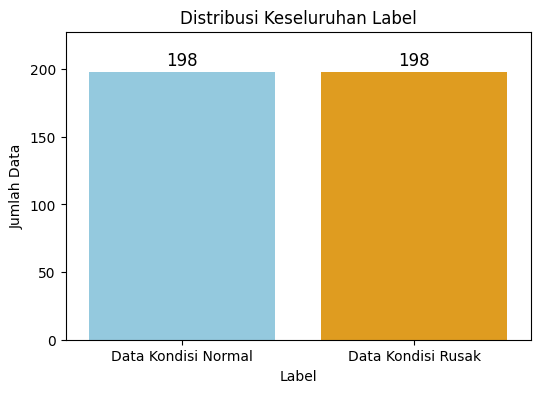

In [72]:
plt.figure(figsize=(6,4))
label_counts = df_labeled[label_col].value_counts()

sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    palette={'Data Kondisi Normal': 'skyblue', 'Data Kondisi Rusak': 'orange'}
)

plt.title("Distribusi Keseluruhan Label")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")

# Tambahkan angka di atas bar
for i, val in enumerate(label_counts.values):
    plt.text(i, val + 5, str(val), ha='center', fontsize=12)  # offset kecil

# Naikkan batas maksimal sumbu Y
plt.ylim(0, max(label_counts.values) * 1.15)  # 15% lebih tinggi dari nilai maksimum

plt.show()


## *4. Isolation Forest Implementation*

#### Isolation Forest Implementation - Train (80% Good Data) Test (20% Good Data + 100% Failure Data)

In [73]:
# --- Pisahkan data normal & anomali berdasarkan label ---
X_normal = X_scaled[y == 0]
X_anomali = X_scaled[y == 1]

# --- Split data normal menjadi train (80%) & test (20%) ---
X_train_normal, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

# --- Buat test set (gabungan normal + anomali) ---
X_test = pd.concat([X_test_normal, X_anomali], ignore_index=True)
y_test = pd.Series([0]*len(X_test_normal) + [1]*len(X_anomali))  # 0=Normal, 1=Anomali


In [74]:
# --- Latih model hanya dengan data normal yang sudah distandarisasi ---
model = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42
)
model.fit(X_train_normal)

# --- Prediksi pada test set ---
y_pred = model.predict(X_test)  # -1 = Anomali, 1 = Normal
y_pred = [1 if val == -1 else 0 for val in y_pred]
anomaly_score = model.decision_function(X_test)

# --- Kembalikan X_test (yang sudah diskalakan) ke nilai aslinya ---
X_test_original = pd.DataFrame(
    scaler.inverse_transform(X_test),
    columns=X.columns
)

# --- Gabungkan hasil prediksi ---
df_hasil = X_test_original.copy()
df_hasil['True_Label'] = y_test.replace({0: 'Normal', 1: 'Anomali'})
df_hasil['Prediksi'] = y_pred
df_hasil['Prediksi_Label'] = pd.Series(y_pred).replace({0: 'Normal', 1: 'Anomali'})
df_hasil['Anomaly_Score'] = anomaly_score


Confusion Matrix (detail):
True Negative (TN) = 23  → Normal diprediksi Normal
False Positive (FP) = 17 → Normal diprediksi Anomali
False Negative (FN) = 1 → Anomali diprediksi Normal
True Positive (TP) = 197  → Anomali diprediksi Anomali

Prediksi Benar Normal  : 23
Prediksi Salah Normal  : 17
Prediksi Benar Anomali : 197
Prediksi Salah Anomali : 1 

Evaluation Metrics:
Accuracy  : 0.9244
Precision : 0.9206
Recall    : 0.9949
F1-score  : 0.9563

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.57      0.72        40
     Anomali       0.92      0.99      0.96       198

    accuracy                           0.92       238
   macro avg       0.94      0.78      0.84       238
weighted avg       0.93      0.92      0.92       238



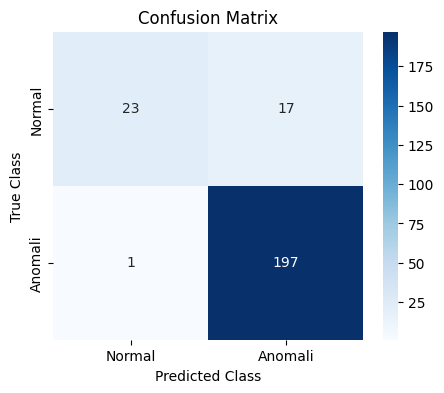

In [75]:
# --- Evaluasi Model ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix (detail):")
print(f"True Negative (TN) = {tn}  → Normal diprediksi Normal")
print(f"False Positive (FP) = {fp} → Normal diprediksi Anomali")
print(f"False Negative (FN) = {fn} → Anomali diprediksi Normal")
print(f"True Positive (TP) = {tp}  → Anomali diprediksi Anomali\n")

print("Prediksi Benar Normal  :", tn)
print("Prediksi Salah Normal  :", fp)
print("Prediksi Benar Anomali :", tp)
print("Prediksi Salah Anomali :", fn, "\n")

# --- Hitung metrik evaluasi ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal','Anomali']))

# --- Plot Confusion Matrix ---
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

In [76]:
# --- Contoh Data Anomali Terdeteksi ---
anomali_terdeteksi = df_hasil[df_hasil['Prediksi'] == 1]
normal_terdeteksi = df_hasil[df_hasil['Prediksi'] == 0]

# --- Informasi Jumlah Data ---
print("Ringkasan Hasil Deteksi:")
print("-------------------------------------")
print(f"Jumlah Data Anomali Terdeteksi : {len(anomali_terdeteksi)}")
print(f"Jumlah Data Normal Terdeteksi  : {len(normal_terdeteksi)}")
print("-------------------------------------")
print(f"Total Data                     : {len(df_hasil)}")

# --- Tampilkan Data Anomali ---
print("\nSeluruh Data Anomali Terdeteksi:")
display(anomali_terdeteksi)

Ringkasan Hasil Deteksi:
-------------------------------------
Jumlah Data Anomali Terdeteksi : 214
Jumlah Data Normal Terdeteksi  : 24
-------------------------------------
Total Data                     : 238

Seluruh Data Anomali Terdeteksi:


,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance,True_Label,Prediksi,Prediksi_Label,Anomaly_Score
1,20.3,8.84,78.0,13.8,21.9,38.0,1.0,1.8,1.0,20.5,...,1.0,0.72,-2.4,2.3,-2.344,27.5,Normal,1,Anomali,-0.000095
3,20.0,12.50,80.0,13.9,23.5,39.6,1.1,1.9,1.1,20.5,...,1.0,0.68,2.3,3.1,2.343,35.0,Normal,1,Anomali,-0.021111
5,19.6,10.35,79.0,13.8,22.7,38.4,1.1,1.9,1.1,20.5,...,1.0,0.72,-3.2,3.1,-3.125,32.0,Normal,1,Anomali,-0.021229
6,20.3,12.62,80.0,13.9,23.5,39.6,1.1,1.9,1.1,20.5,...,1.0,0.05,0.7,3.1,0.781,34.5,Normal,1,Anomali,-0.018042
7,17.6,5.53,75.0,13.8,20.3,36.0,1.0,1.7,1.0,20.0,...,1.0,0.07,7.8,1.5,7.812,23.5,Normal,1,Anomali,-0.094126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,23.9,4.25,84.0,13.6,15.6,31.7,0.7,1.5,0.7,19.5,...,1.0,0.01,4.6,0.7,4.687,10.5,Anomali,1,Anomali,-0.070452
234,24.7,4.03,84.0,13.5,15.6,31.7,0.7,1.5,0.7,19.5,...,1.0,0.01,5.4,0.7,5.468,10.5,Anomali,1,Anomali,-0.075314
235,26.6,4.10,84.0,13.5,15.6,31.7,0.7,1.5,0.7,19.5,...,1.0,0.01,6.2,0.7,6.250,10.5,Anomali,1,Anomali,-0.111618
236,28.2,4.06,84.0,13.5,15.6,31.7,0.7,1.5,0.7,19.5,...,1.0,0.01,7.0,0.7,7.031,10.5,Anomali,1,Anomali,-0.120387


In [77]:
display(normal_terdeteksi)

,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance,True_Label,Prediksi,Prediksi_Label,Anomaly_Score
0,20.7,12.89,76.0,13.8,23.5,39.6,1.1,1.9,1.1,20.0,...,1.0,0.72,3.1,3.1,3.125,34.5,Normal,0,Normal,0.022781
2,19.6,2.93,75.0,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,1.0,0.09,1.5,2.3,1.562,7.0,Normal,0,Normal,0.110104
4,18.8,3.21,80.0,13.8,16.0,31.7,0.8,1.5,0.8,20.0,...,1.0,0.03,3.1,2.3,3.125,7.0,Normal,0,Normal,0.074986
8,19.6,2.93,75.0,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,1.0,0.09,2.3,2.3,2.343,6.5,Normal,0,Normal,0.101868
9,18.4,2.98,81.0,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,1.0,0.72,-1.6,2.3,-1.563,11.5,Normal,0,Normal,0.071613
10,18.0,3.20,80.0,13.8,16.0,31.7,0.8,1.5,0.8,20.0,...,1.0,0.76,2.3,2.3,2.343,9.5,Normal,0,Normal,0.076099
11,20.0,2.93,75.0,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,1.0,0.29,0.7,2.3,0.781,8.5,Normal,0,Normal,0.107029
13,20.0,11.46,76.0,13.8,23.1,38.8,1.1,1.9,1.1,20.0,...,1.0,0.07,-0.8,3.9,-0.782,34.0,Normal,0,Normal,0.006306
17,19.2,2.92,75.0,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,1.0,0.76,1.5,2.3,1.562,6.5,Normal,0,Normal,0.106799
19,18.8,3.23,78.0,13.8,16.0,31.7,0.8,1.5,0.8,20.0,...,1.0,0.01,2.3,2.3,2.343,7.0,Normal,0,Normal,0.071029


##### SHAP Value (Find Trouble Parameter)

In [78]:
import shap

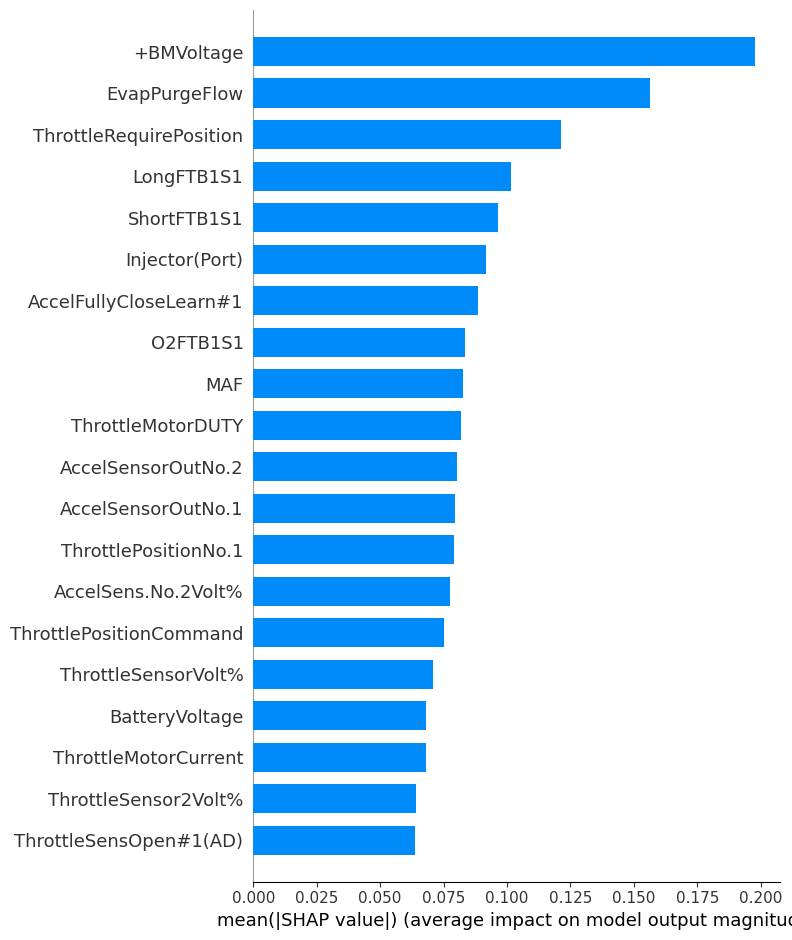

In [79]:
# --- Buat explainer untuk Isolation Forest ---
explainer = shap.TreeExplainer(model)

# --- Hitung shap values untuk seluruh dataset ---
shap_values = explainer.shap_values(X_scaled)

# --- Filter hanya data yang diprediksi Anomali ---
anomali_idx = df_hasil[df_hasil['Prediksi_Label'] == 'Anomali'].index
X_anomali = X_scaled.loc[anomali_idx]
shap_values_anomali = shap_values[anomali_idx]

# --- Visualisasi: summary plot untuk anomali ---
shap.summary_plot(shap_values_anomali, X_anomali, plot_type="bar")
print ("\n")
# --- Alternatif visualisasi lebih detail (beeswarm) ---
# shap.summary_plot(shap_values_anomali, X_anomali)

In [80]:
# Ambil SHAP value absolut rata-rata
mean_abs_shap = pd.DataFrame({
    'Fitur': X_anomali.columns,
    'Mean|SHAP|': np.round(np.abs(shap_values_anomali).mean(axis=0), 2)
}).sort_values('Mean|SHAP|', ascending=False)

display(mean_abs_shap.head(25))

,Fitur,Mean|SHAP|
23,+BMVoltage,0.20
26,EvapPurgeFlow,0.16
13,ThrottleRequirePosition,0.12
30,LongFTB1S1,0.10
29,ShortFTB1S1,0.10
24,Injector(Port),0.09
9,AccelFullyCloseLearn#1,0.09
20,ThrottleMotorDUTY,0.08
1,MAF,0.08
6,AccelSensorOutNo.1,0.08
